In [1]:
import os
import numpy as np
import pandas as pd
import gemmi



In [2]:
def get_resolution(emdb_id: str) -> float | None:
    """
    Fetch the resolution of an EMDB entry using the EMDB REST API.
    
    Args:
        emdb_id (str): EMDB accession ID (e.g., "EMD-5778").
    
    Returns:
        float | None: Resolution in Å if available, otherwise None.
    """
    # API endpoint for EMDB JSON data
    import requests
    url = f"https://www.ebi.ac.uk/emdb/api/entry/{emdb_id}"
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
    except Exception as e:
        print(f"Error fetching data for {emdb_id}: {e}")
        return None

    try:
        # Navigate JSON structure safely
        structure_determinations = data.get("structure_determination_list", {}).get("structure_determination", [])
        for sd in structure_determinations:
            for ip in sd.get("image_processing", []):
                final_rec = ip.get("final_reconstruction", {})
                resolution = final_rec.get("resolution", {})
                if "valueOf_" in resolution:
                    return float(resolution["valueOf_"])
    except Exception as e:
        print(f"Error parsing resolution for {emdb_id}: {e}")
        return None

    return None

In [3]:
parent_folder_predictions = "//home/abharadwaj1/papers/elife_paper/figure_information/data/model_angelo_predictions_new_version"
model_angelo_training_dataset = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/processed/pdbs/figure_7/modelangelo_training_dataset.csv"

suffix = "_only_outside_training"
model_angelo_training_ids = pd.read_csv(model_angelo_training_dataset)
model_angelo_training_emdbs = model_angelo_training_ids["EMDB Map"].tolist()
emdb_in_model_angelo_training = [x.split("-")[1] for x in model_angelo_training_emdbs]


num_atoms_using_hybrid = {}
num_atoms_using_unsharpened = {}
num_atoms_using_deposited = {}

num_atoms_using_hybrid_raw = {}
num_atoms_using_unsharpened_raw = {}
num_atoms_using_deposited_raw = {}

num_residues_using_hybrid = {}
num_residues_using_unsharpened = {}
num_residues_using_deposited = {}

num_residues_using_hybrid_raw = {}
num_residues_using_unsharpened_raw = {}
num_residues_using_deposited_raw = {}

def get_num_residues(structure):
    num_residues = 0
    for chain in structure[0]:
        num_residues += len(chain)
    return num_residues

for emdb_pdb in os.listdir(parent_folder_predictions):
    
    # make sure emdb_pdb is a string
    if not isinstance(emdb_pdb, str):
        continue
    
    emdb, pdb = emdb_pdb.split("_")
    #emdb = emdb_pdb
    if emdb not in emdb_in_model_angelo_training:
        print(f"Skipping {emdb} as it is not in the training set")
        continue
    
    emdb_folder = os.path.join(parent_folder_predictions, emdb_pdb)

    # make sure emdb_folder is a folder
    if not os.path.isdir(emdb_folder):
        print(f"Skipping {emdb} as {emdb_folder} is not a directory")
        continue

    resolution_emdb = get_resolution(emdb)
    if resolution_emdb > 4.0 or resolution_emdb is None:
        print(f"Skipping {emdb} with resolution {resolution_emdb}")
        continue

    model_angelo_predicted_structure_hybrid = os.path.join(emdb_folder, f"emd_{emdb}_model_angelo_hybrid", f"emd_{emdb}_model_angelo_hybrid.cif")
    model_angelo_predicted_structure_unsharpened = os.path.join(emdb_folder, f"emd_{emdb}_model_angelo_unsharpened", f"emd_{emdb}_model_angelo_unsharpened.cif")
    model_angelo_predicted_structure_deposited = os.path.join(emdb_folder, f"emd_{emdb}_model_angelo_deposited", f"emd_{emdb}_model_angelo_deposited.cif")

    model_angelo_predicted_structure_hybrid_raw = os.path.join(emdb_folder, f"emd_{emdb}_model_angelo_hybrid", f"emd_{emdb}_model_angelo_hybrid_raw.cif")
    model_angelo_predicted_structure_unsharpened_raw = os.path.join(emdb_folder, f"emd_{emdb}_model_angelo_unsharpened", f"emd_{emdb}_model_angelo_unsharpened_raw.cif")
    model_angelo_predicted_structure_deposited_raw = os.path.join(emdb_folder, f"emd_{emdb}_model_angelo_deposited", f"emd_{emdb}_model_angelo_deposited_raw.cif")

    # make sure all files exist
    hybrid_file_exists = os.path.isfile(model_angelo_predicted_structure_hybrid)
    unsharpened_file_exists = os.path.isfile(model_angelo_predicted_structure_unsharpened)
    deposited_file_exists = os.path.isfile(model_angelo_predicted_structure_deposited)

    hybrid_file_exists_raw = os.path.isfile(model_angelo_predicted_structure_hybrid_raw)
    unsharpened_file_exists_raw = os.path.isfile(model_angelo_predicted_structure_unsharpened_raw)
    deposited_file_exists_raw = os.path.isfile(model_angelo_predicted_structure_deposited_raw)


    if not (hybrid_file_exists and unsharpened_file_exists) or not (hybrid_file_exists_raw and unsharpened_file_exists_raw):# or not (deposited_file_exists and deposited_file_exists_raw):
        print(f"Skipping {emdb} as one of the files does not exist")
        continue

    # read in the structures
    # deposited_structure = gemmi.read_structure(model_angelo_predicted_structure_deposited) 
    hybrid_structure = gemmi.read_structure(model_angelo_predicted_structure_hybrid)
    unsharpened_structure = gemmi.read_structure(model_angelo_predicted_structure_unsharpened)

    # deposited_structure_raw = gemmi.read_structure(model_angelo_predicted_structure_deposited_raw)
    hybrid_structure_raw = gemmi.read_structure(model_angelo_predicted_structure_hybrid_raw)
    unsharpened_structure_raw = gemmi.read_structure(model_angelo_predicted_structure_unsharpened_raw)

    # get the number of atoms in each structure
    # num_atoms_deposited = deposited_structure[0].count_atom_sites()
    num_atoms_hybrid = hybrid_structure[0].count_atom_sites()
    num_atoms_unsharpened = unsharpened_structure[0].count_atom_sites()

    # num_atoms_deposited_raw = deposited_structure_raw[0].count_atom_sites()
    num_atoms_hybrid_raw = hybrid_structure_raw[0].count_atom_sites()
    num_atoms_unsharpened_raw = unsharpened_structure_raw[0].count_atom_sites()

    # get the number of residues in each structure
    # num_residues_deposited = get_num_residues(deposited_structure)
    num_residues_hybrid = get_num_residues(hybrid_structure)
    num_residues_unsharpened = get_num_residues(unsharpened_structure)

    # num_residues_deposited_raw = get_num_residues(deposited_structure_raw)
    num_residues_hybrid_raw = get_num_residues(hybrid_structure_raw)
    num_residues_unsharpened_raw = get_num_residues(unsharpened_structure_raw)

    # add the number of atoms to the dictionary
    # num_atoms_using_deposited[emdb] = num_atoms_deposited
    num_atoms_using_hybrid[emdb] = num_atoms_hybrid
    num_atoms_using_unsharpened[emdb] = num_atoms_unsharpened

    # num_atoms_using_deposited_raw[emdb] = num_atoms_deposited_raw
    num_atoms_using_hybrid_raw[emdb] = num_atoms_hybrid_raw
    num_atoms_using_unsharpened_raw[emdb] = num_atoms_unsharpened_raw

    
    # add the number of residues to the dictionary
    # num_residues_using_deposited[emdb] = num_residues_deposited
    num_residues_using_hybrid[emdb] = num_residues_hybrid
    num_residues_using_unsharpened[emdb] = num_residues_unsharpened

    # num_residues_using_deposited_raw[emdb] = num_residues_deposited_raw
    num_residues_using_hybrid_raw[emdb] = num_residues_hybrid_raw
    num_residues_using_unsharpened_raw[emdb] = num_residues_unsharpened_raw



print(f"Total length after filtering: {len(num_residues_using_hybrid)}")

Skipping 0665 as it is not in the training set
Skipping 0038 as it is not in the training set
Skipping 0071 as it is not in the training set
Skipping 0132 as it is not in the training set
Skipping 0408 as it is not in the training set
Skipping 0415 as one of the files does not exist
Skipping 4288 as it is not in the training set
Skipping 0452 as one of the files does not exist
Skipping 0490 as it is not in the training set
Skipping 0492 as it is not in the training set
Skipping 0589 as it is not in the training set
Skipping 10049 as one of the files does not exist
Skipping 10100 as it is not in the training set
Skipping 10273 as it is not in the training set
Skipping 10324 as it is not in the training set
Skipping 10534 as it is not in the training set
Skipping 10617 as it is not in the training set
Skipping 20146 as it is not in the training set
Skipping 20270 as it is not in the training set
Skipping 20271 as it is not in the training set
Skipping 20986 as it is not in the training s

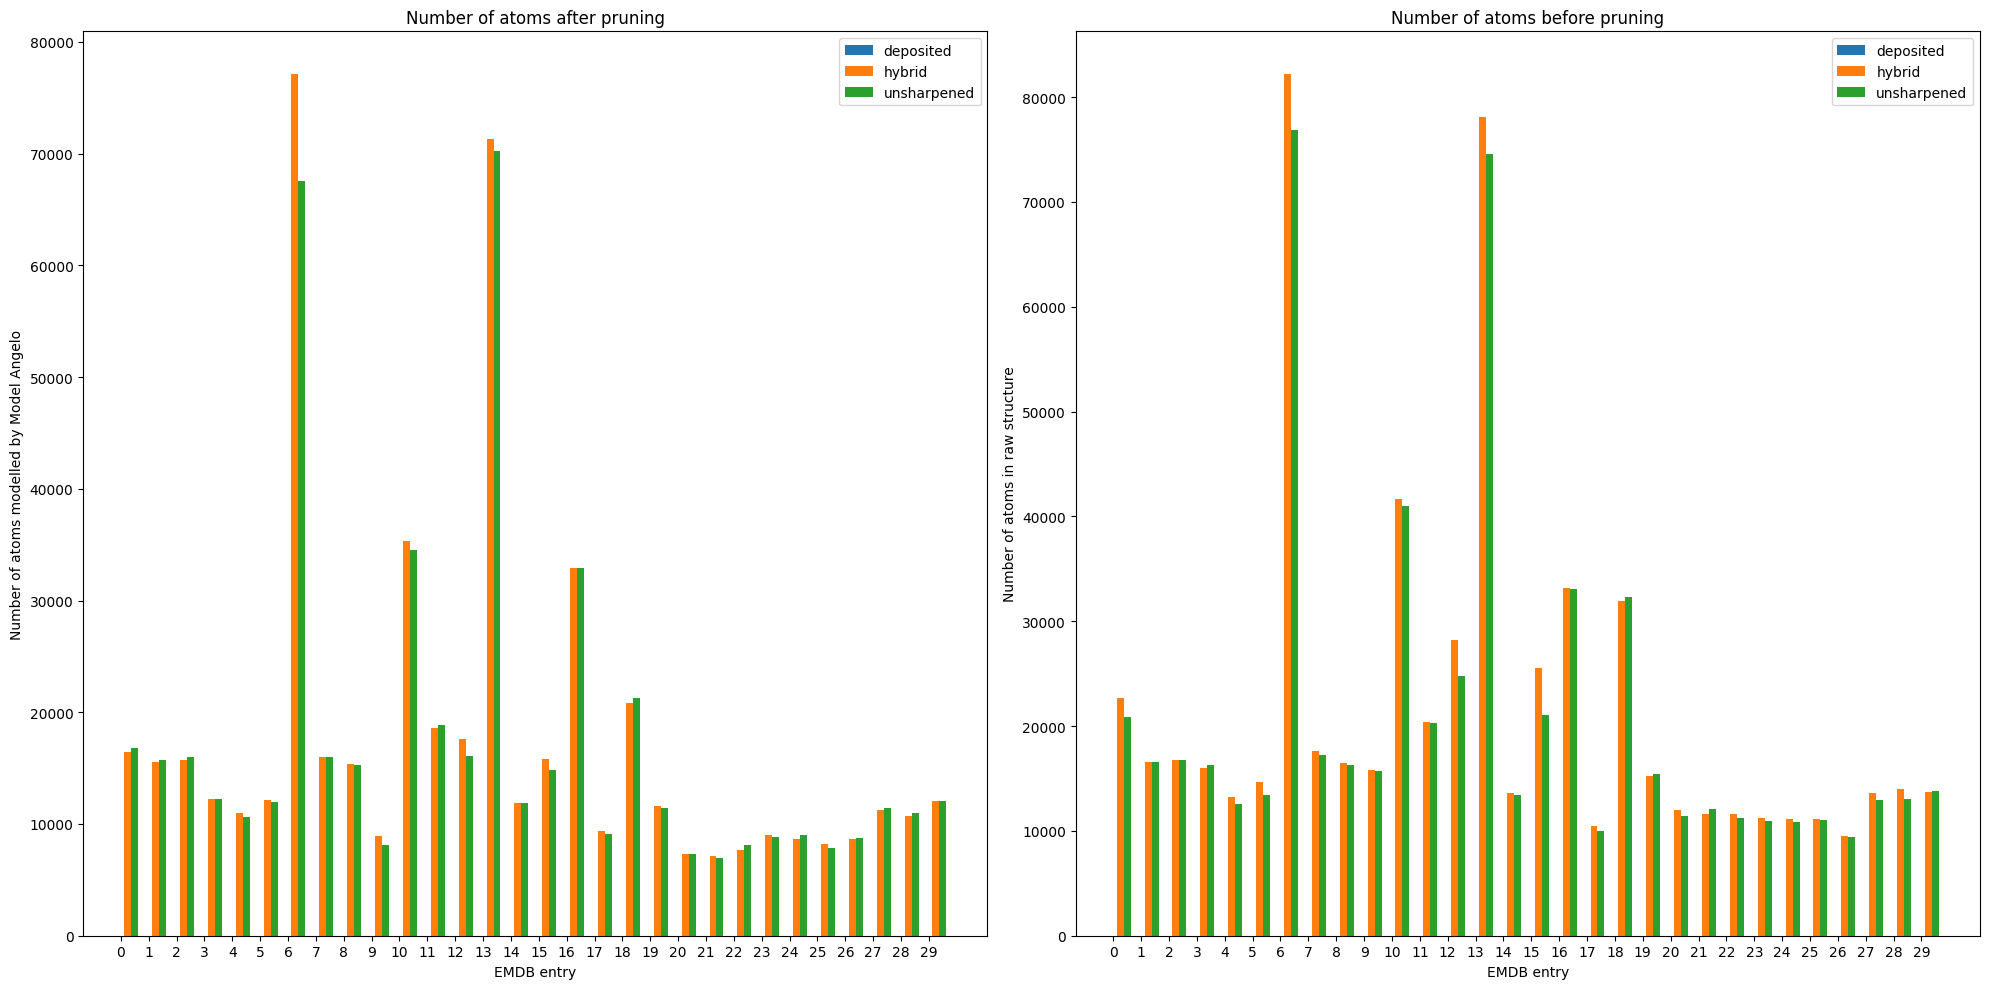

In [4]:
# Plot the number of atoms in each type of structure for each EMDB entry as a bar plot
import matplotlib.pyplot as plt

# make sure the number of entries in each dictionary is the same
assert len(num_atoms_using_hybrid) == len(num_atoms_using_unsharpened)

num_atoms_deposited_list = list(num_atoms_using_deposited.values())
num_atoms_hybrid_list = list(num_atoms_using_hybrid.values())
num_atoms_unsharpened_list = list(num_atoms_using_unsharpened.values())

num_atoms_deposited_list_raw = list(num_atoms_using_deposited_raw.values())
num_atoms_hybrid_list_raw = list(num_atoms_using_hybrid_raw.values())
num_atoms_unsharpened_list_raw = list(num_atoms_using_unsharpened_raw.values())

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].bar(np.arange(len(num_atoms_deposited_list)), num_atoms_deposited_list, width=0.25, label="deposited");
ax[0].bar(np.arange(len(num_atoms_hybrid_list)) + 0.25, num_atoms_hybrid_list, width=0.25, label="hybrid");
ax[0].bar(np.arange(len(num_atoms_unsharpened_list)) + 0.5, num_atoms_unsharpened_list, width=0.25, label="unsharpened");
ax[0].set_xticks(np.arange(len(num_atoms_hybrid_list)))
ax[0].set_ylabel("Number of atoms modelled by Model Angelo")
ax[0].set_xlabel("EMDB entry")
ax[0].set_title("Number of atoms after pruning")
ax[0].legend()

# plot the number of atoms in the raw structures
ax[1].bar(np.arange(len(num_atoms_deposited_list_raw)), num_atoms_deposited_list_raw, width=0.25, label="deposited");
ax[1].bar(np.arange(len(num_atoms_hybrid_list_raw)) + 0.25, num_atoms_hybrid_list_raw, width=0.25, label="hybrid");
ax[1].bar(np.arange(len(num_atoms_unsharpened_list_raw)) + 0.5, num_atoms_unsharpened_list_raw, width=0.25, label="unsharpened");
ax[1].set_xticks(np.arange(len(num_atoms_hybrid_list_raw)))
ax[1].set_ylabel("Number of atoms in raw structure")
ax[1].set_xlabel("EMDB entry")
ax[1].set_title("Number of atoms before pruning")
ax[1].legend()

plt.tight_layout()




In [5]:
# # Plot the number of residues in each type of structure for each EMDB entry as a bar plot
# import matplotlib.pyplot as plt

# # make sure the number of entries in each dictionary is the same
# assert  len(num_residues_using_hybrid) == len(num_residues_using_unsharpened)

# num_residues_hybrid_list = list(num_residues_using_hybrid.values())
# num_residues_unsharpened_list = list(num_residues_using_unsharpened.values())

# num_residues_hybrid_list_raw = list(num_residues_using_hybrid_raw.values())
# num_residues_unsharpened_list_raw = list(num_residues_using_unsharpened_raw.values())


# fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# #ax[0].bar(np.arange(len(num_residues_deposited_list)), num_residues_deposited_list, width=0.25, label="deposited");
# ax[0].bar(np.arange(len(num_residues_hybrid_list)) + 0.25, num_residues_hybrid_list, width=0.25, label="hybrid");
# ax[0].bar(np.arange(len(num_residues_unsharpened_list)) + 0.5, num_residues_unsharpened_list, width=0.25, label="unsharpened");
# ax[0].set_xticks(np.arange(len(num_residues_hybrid_list)))
# ax[0].set_ylabel("Number of residues modelled by Model Angelo")
# ax[0].set_xlabel("EMDB entry")
# ax[0].set_title("Number of residues after pruning")
# ax[0].legend()

# # plot the number of atoms in the raw structures
# #ax[1].bar(np.arange(len(num_residues_deposited_list_raw)), num_residues_deposited_list_raw, width=0.25, label="deposited");
# ax[1].bar(np.arange(len(num_residues_hybrid_list_raw)) + 0.25, num_residues_hybrid_list_raw, width=0.25, label="hybrid");
# ax[1].bar(np.arange(len(num_residues_unsharpened_list_raw)) + 0.5, num_residues_unsharpened_list_raw, width=0.25, label="unsharpened");
# ax[1].set_xticks(np.arange(len(num_residues_hybrid_list_raw)))
# ax[1].set_ylabel("Number of residues in raw structure")
# ax[1].set_xlabel("EMDB entry")
# ax[1].set_title("Number of residues before pruning")
# ax[1].legend()

# plt.tight_layout()

Text(0.5, 1.0, 'Number of residues after pruning')

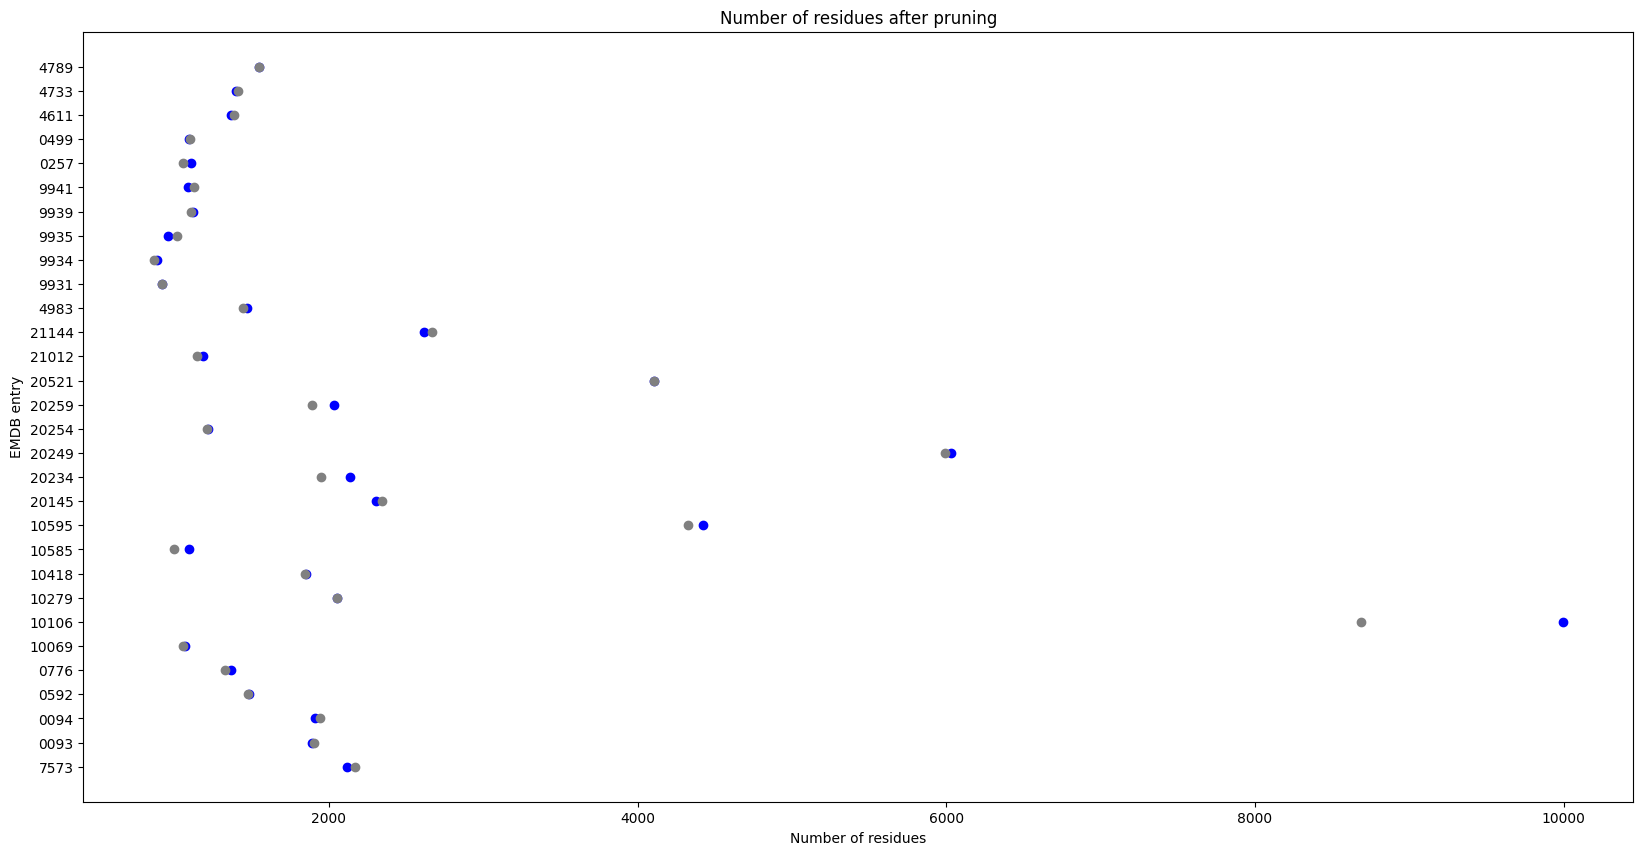

In [6]:
# Draw a plot such that along Y axis we arrange the EMDB entries and along X axis we plot the number of residues in each structure
# For each EMDB entry, we plot three dots, one for "deposited", one for "hybrid" and one for "unsharpened". 
# these dots have consistent color
# deposited: brown, hybrid: blur, unsharpened: gray

import matplotlib.pyplot as plt
emdb_list = list(num_residues_using_hybrid.keys())
#num_residues_deposited_list = list(num_residues_using_deposited.values())
num_residues_hybrid_list = list(num_residues_using_hybrid.values())
num_residues_unsharpened_list = list(num_residues_using_unsharpened.values())

#num_residues_deposited_list_raw = list(num_residues_using_deposited_raw.values())
num_residues_hybrid_list_raw = list(num_residues_using_hybrid_raw.values())
num_residues_unsharpened_list_raw = list(num_residues_using_unsharpened_raw.values())

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
#ax.scatter(num_residues_deposited_list, emdb_list, color="brown", label="deposited");
ax.scatter(num_residues_hybrid_list, emdb_list, color="blue", label="hybrid");
ax.scatter(num_residues_unsharpened_list, emdb_list, color="gray", label="unsharpened");
ax.set_yticks(np.arange(len(emdb_list)))
ax.set_yticklabels(emdb_list, rotation=0)
ax.set_xlabel("Number of residues")
ax.set_ylabel("EMDB entry")
ax.set_title("Number of residues after pruning")




In [7]:
# Plot the same as above but now arrange the EMDB list based on the number of residues in the unsharpened structure
import matplotlib.pyplot as plt

# make sure the number of entries in each dictionary is the same
assert len(num_residues_using_hybrid) == len(num_residues_using_unsharpened)

emdb_list_ordered = [emdb for _, emdb in sorted(zip(num_residues_unsharpened_list_raw, emdb_list))]
#num_residues_deposited_list_ordered = [num_residues_using_deposited[emdb] for emdb in emdb_list_ordered]
num_residues_hybrid_list_ordered = [num_residues_using_hybrid[emdb] for emdb in emdb_list_ordered]
num_residues_unsharpened_list_ordered = [num_residues_using_unsharpened[emdb] for emdb in emdb_list_ordered]
#num_residues_deposited_raw_list_ordered = [num_residues_using_deposited_raw[emdb] for emdb in emdb_list_ordered]
num_residues_hybrid_raw_list_ordered = [num_residues_using_hybrid_raw[emdb] for emdb in emdb_list_ordered]
num_residues_unsharpened_raw_list_ordered = [num_residues_using_unsharpened_raw[emdb] for emdb in emdb_list_ordered]


In [8]:
# Now plot the difference between the number of residues using hybrid map versus the number of residues using unsharpened map
# along Y axis we arrange the EMDB entries and along X axis we plot the difference between the number of residues in each structure
# We do not care about deposited structures here

import matplotlib.pyplot as plt

# make sure the number of entries in each dictionary is the same
assert len(num_residues_using_hybrid) == len(num_residues_using_unsharpened)


num_residues_difference_before_pruning = [num_residues_hybrid_raw_list_ordered[i] - num_residues_unsharpened_raw_list_ordered[i] for i in range(len(emdb_list_ordered))]
#num_residues_difference_before_pruning_deposited = [num_residues_hybrid_raw_list_ordered[i] - num_residues_deposited_raw_list_ordered[i] for i in range(len(emdb_list_ordered))]

num_residues_difference_after_pruning = [num_residues_hybrid_list_ordered[i] - num_residues_unsharpened_list_ordered[i] for i in range(len(emdb_list_ordered))]
#num_residues_difference_after_pruning_deposited = [num_residues_hybrid_list_ordered[i] - num_residues_deposited_list_ordered[i] for i in range(len(emdb_list_ordered))]







In [9]:
import json 


def plot_difference_plots(emdb_entry_list, difference_array, xlabel, ylabel, title, figsize_cm=(14,8), \
                        marker="o", markersize=12,fontscale=2.5,font="Helvetica", \
                        linewidth=2,legends=None, num_yticks=5,emdb_list_to_show=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    import matplotlib as mpl
    mpl.rcParams['pdf.fonttype'] = 42

    sns.set_theme(context="paper", font="Helvetica", font_scale=fontscale)
    sns.set_style("white")
    kwargs = dict(linewidth=linewidth)
    # set font size 
    #plt.rcParams.update({'font.size': })
    figsize = (figsize_cm[0]/2.54, figsize_cm[1]/2.54)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    # print percentage positive 
    percent_positive = sum([1 for x in difference_array if x > 0]) / len(difference_array) * 100
    print(f"Percentage positive: {percent_positive:.2f}%")
    # arrange the data such that the negative differences are to the left and positive differences are to the right
    # this is to make the plot look nicer
    # we also arrange the EMDB entries in the same order

    # first we get the indices of the sorted array
    sorted_indices = np.argsort(difference_array)
    # then we get the sorted array
    sorted_array = np.sort(difference_array)
    # then we get the sorted EMDB entries
    sorted_emdb_entries = [emdb_entry_list[i] for i in sorted_indices]
    
    
    for i, emdb in enumerate(sorted_emdb_entries):
        print(emdb, get_resolution(emdb), sorted_array[i])
    

    # now we plot the data as a horizontal bar plot
    # we also add a text label next to the select few EMDB entries based on emdb_list_to_show 

    ax.barh(np.arange(len(emdb_entry_list)), sorted_array, color=["blue" if sorted_array[i] > 0 else "red" for i in range(len(emdb_entry_list))])

    # now we add the text labels
    if emdb_list_to_show is not None:
        for i in range(len(sorted_emdb_entries)):
            if sorted_emdb_entries[i] in emdb_list_to_show:
                emdb_right = True if sorted_array[i] > 0 else False
                if emdb_right:
                    x_distance = 100
                    y_distance = -2
                else:
                    x_distance = -500
                    y_distance = 2

                ax.text(sorted_array[i]+x_distance,i+y_distance, sorted_emdb_entries[i], ha='left', va='center', fontsize=fontscale*10)
                # draw a line from the text label to the bar
                if emdb_right:
                    ax.plot([sorted_array[i], sorted_array[i]+x_distance], [i, i+y_distance], color="black", linewidth=1)
                else:
                    ax.plot([sorted_array[i], sorted_array[i]+x_distance+400], [i, i+y_distance], color="black", linewidth=1)

    # do not show yticks
    ax.set_yticks([])

    # set x limits
    ax.set_xlim([-1200, 1400])
    
    # set x ticks at -1000, 0, 1000
    ax.set_xticks([-1000, 0, 1000])
    # set x tick labels
    ax.set_xticklabels(["-1000", "0", "1000"])
    
    # now we draw a vertical line at x=0
    ax.axvline(x=0, color="black", linestyle="--", linewidth=linewidth)

    ax.set_xlabel(xlabel)
    # now we set the ylabel
    ax.set_ylabel(ylabel)
    # now we set the title
    ax.set_title(title)
    # now we set the legend
    if legends is not None:
        ax.legend(legends)

    sns.despine()
    
    plt.tight_layout()
    return fig, ax

Percentage positive: 80.00%
9934 3.22 -51
21144 3.1 -44
4983 3.5 -30
0592 3.15 -12
4789 3.2 -9
0257 3.7 -1
0093 3.4 5
20521 2.1 9
0094 3.4 15
20254 3.6 16
0499 2.7 20
10418 2.96 23
9939 2.83 26
10585 3.7 26
20145 3.3 37
9941 2.95 47
9935 3.08 50
10279 3.33 59
0776 2.67 65
9931 3.3 85
21012 3.8 90
4611 3.2 92
10595 3.25 117
10069 3.2 140
4733 3.65 140
7573 3.2 242
20249 3.2 300
20234 3.8 468
20259 3.57 702
10106 3.5 780


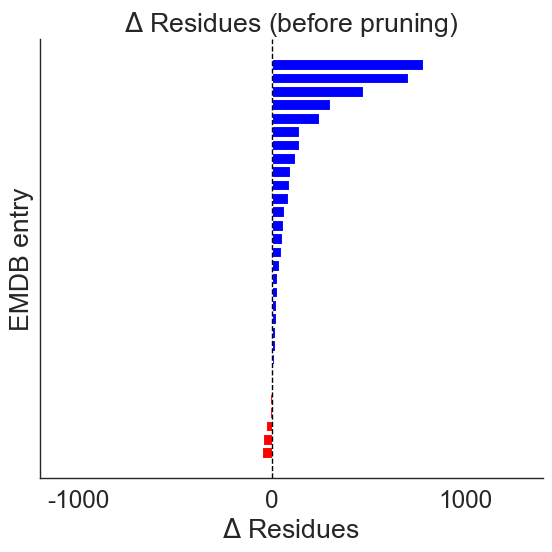

In [10]:

# plot the difference between the number of residues using hybrid map versus the number of residues (AFTER PRUNING) using unsharpened maps
ylabel = "EMDB entry"
xlabel = r"$\Delta$ Residues"
title = r"$\Delta$ Residues (before pruning)"
emdb_list = [x for x in emdb_list_ordered]
emdb_list_to_show = None #["0071", "8958"]
fig, ax = plot_difference_plots(emdb_list, num_residues_difference_before_pruning, xlabel, ylabel, title, figsize_cm=(15,15), \
                                marker="o", markersize=6,fontscale=2,font="Helvetica", \
                                linewidth=1,legends=None, num_yticks=6,emdb_list_to_show=emdb_list_to_show)

#fig.savefig(f"difference_in_num_residues_newdataset_{suffix}_before_pruning.pdf", dpi=600, bbox_inches="tight")


Percentage positive: 60.00%
9935 3.08 -64
21144 3.1 -54
7573 3.2 -52
9941 2.95 -43
20145 3.3 -36
0094 3.4 -30
4733 3.65 -18
4611 3.2 -17
0499 2.7 -12
0093 3.4 -12
4789 3.2 -1
9931 3.3 0
20521 2.1 1
10279 3.33 2
10418 2.96 7
20254 3.6 7
0592 3.15 8
10069 3.2 10
9939 2.83 12
9934 3.22 21
4983 3.5 27
21012 3.8 40
0776 2.67 40
20249 3.2 42
0257 3.7 53
10585 3.7 99
10595 3.25 103
20259 3.57 145
20234 3.8 192
10106 3.5 1306


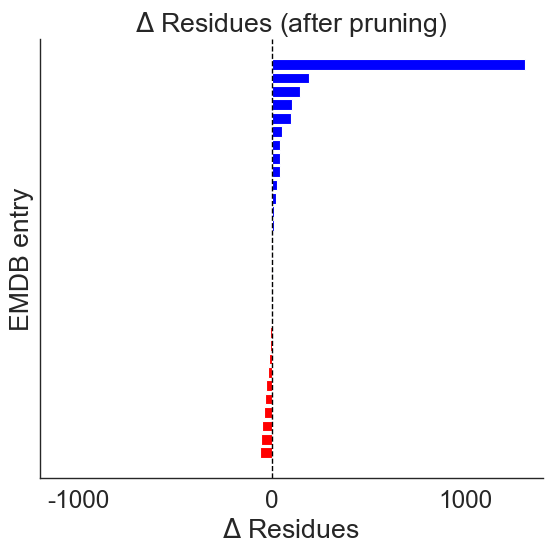

In [11]:
# plot the difference between the number of residues using hybrid map versus the number of residues (BEFORE PRUNING) using unsharpened maps
ylabel = "EMDB entry"
xlabel = r"$\Delta$ Residues"
title = r"$\Delta$ Residues (after pruning)"
emdb_list = [x.split("_")[0] for x in emdb_list_ordered]
fig, ax = plot_difference_plots(emdb_list, num_residues_difference_after_pruning, xlabel, ylabel, title, figsize_cm=(15,15), \
                                marker="o", markersize=6,fontscale=2,font="Helvetica", \
                                linewidth=1,legends=None, num_yticks=6,emdb_list_to_show=emdb_list_to_show)

#fig.savefig(f"difference_in_num_residues_newdataset_{suffix}_after_pruning.pdf", dpi=600, bbox_inches="tight")


In [12]:
# dump all data to a json file
# data_to_dump = {
#     "emdb_list_ordered": emdb_list_ordered,
#     "num_residues_hybrid_list_ordered": num_residues_hybrid_list_ordered,
#     "num_residues_unsharpened_list_ordered": num_residues_unsharpened_list_ordered,
#     "num_residues_hybrid_raw_list_ordered": num_residues_hybrid_raw_list_ordered,
#     "num_residues_unsharpened_raw_list_ordered": num_residues_unsharpened_raw_list_ordered,
#     "num_residues_difference_before_pruning": num_residues_difference_before_pruning,
#     "num_residues_difference_after_pruning": num_residues_difference_after_pruning
# }

# folder = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/outputs/model_angelo"
# save_path = os.path.join(folder, f"num_residues_data_outside_training_data.json")
# with open(save_path, "w") as f:
#     json.dump(data_to_dump, f, indent=4)

In [ ]:

def jsonify_dictionary(input_dict):
    # convert pickle object to json object
    new_dict = {}
    for key, value in input_dict.items():
        key = str(key) 
        value_is_iterable = isinstance(value, (list, tuple, np.ndarray))
        value_is_dict = isinstance(value, dict)
        value_is_float = isinstance(value, float)
        value_is_int = isinstance(value, (np.int64, int, np.int32))
        value_is_string = isinstance(value, str)
        
        # print("key: {}, value_is_iterable: {}, value_is_dict: {}, value_is_float: {}, \
        #       value_is_int: {}, value_is_string: {}".format(key, value_is_iterable, \
        #                                                     value_is_dict, value_is_float, value_is_int, value_is_string))
        
        if value_is_dict:
            new_value = jsonify_dictionary(value)
        elif value_is_iterable:
            new_value = [str(x) for x in value]
        elif not value_is_string:
            new_value = str(value)
        
        new_dict[key] = new_value
        
    
    return new_dict 

In [ ]:
# Dump the data to a json file
import json 

model_angel_results = {}
model_angelo_results = {
    "using_unsharpened_maps": {
        "num_residues_before_pruning": num_residues_using_unsharpened_raw,
        "num_residues_after_pruning": num_residues_using_unsharpened,
    },
    "using_hybrid_maps": {
        "num_residues_before_pruning": num_residues_using_hybrid_raw,
        "num_residues_after_pruning": num_residues_using_hybrid,
    },
}

output_json_folder = "/home/abharadwaj1/papers/elife_paper/figure_information/outputs/model_angelo_analysis"

with open(os.path.join(output_json_folder, "model_angelo_results_newdataset.json"), "w") as f:
    json.dump(jsonify_dictionary(model_angelo_results), f, indent=4)

    